<a href="https://colab.research.google.com/github/mohnishjason12/Stock-Market-Price-Prediction/blob/main/Stock_Price_prediction%20using%20LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1277132313.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


Data points: 2693
Training model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1039
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.7492e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.1181e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.3445e-04
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.2469e-04
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 4.2921e-04
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 4.0724e-04
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.4351e-04
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.5779e-04
Epoch 10/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 3.8181e-04
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.7232e-04
Epoch 12/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.2910e-04
Epoch 13/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 3.1029e-04
Epoch 14/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.3314e-04
Epoch 15/20
58/58 ━━━━━━━━━━━━

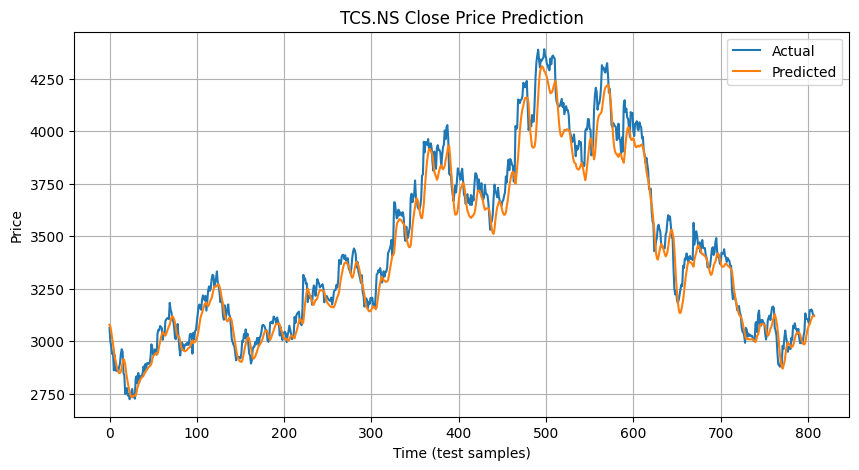

In [2]:
# Very simple LSTM stock prediction script
# Requirements:
# pip install yfinance pandas numpy matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --------- SETTINGS (change if you want) ----------
TICKER = "TCS.NS"         # any valid Yahoo Finance symbol
START_DATE = "2015-01-01"
END_DATE = None           # None = today
WINDOW_SIZE = 60          # how many past days to look at
EPOCHS = 20               # keep small for quick run
BATCH_SIZE = 32
# --------------------------------------------------

def load_data(ticker, start, end=None):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        raise ValueError("No data downloaded. Check ticker or dates.")
    return df[["Close"]].dropna()

def make_sequences(series, window_size):
    """
    series: numpy array of shape (N, 1)
    returns x: (N-window, window_size, 1), y: (N-window, 1)
    """
    x, y = [], []
    for i in range(window_size, len(series)):
        x.append(series[i-window_size:i, 0])
        y.append(series[i, 0])
    x = np.array(x)
    y = np.array(y)
    x = np.reshape(x, (x.shape[0], x.shape[1], 1))
    return x, y

def main():
    print(f"Downloading data for {TICKER}...")
    df = load_data(TICKER, START_DATE, END_DATE)
    print("Data points:", len(df))

    # Train-test split (70% train, 30% test)
    split_index = int(len(df) * 0.7)
    train = df.iloc[:split_index]
    test = df.iloc[split_index:]

    # Scale prices based on training data only
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train.values)
    test_scaled = scaler.transform(test.values)

    # Build training sequences
    x_train, y_train = make_sequences(train_scaled, WINDOW_SIZE)

    # For test, we need the last WINDOW_SIZE points of train + all of test
    last_train = train_scaled[-WINDOW_SIZE:]
    test_input = np.vstack([last_train, test_scaled])
    x_test, y_test = make_sequences(test_input, WINDOW_SIZE)

    # Build simple LSTM model
    model = Sequential()
    model.add(LSTM(50, activation="relu", input_shape=(WINDOW_SIZE, 1)))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mean_squared_error")

    print("Training model...")
    history = model.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Predict
    y_pred_scaled = model.predict(x_test)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1))
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae = mean_absolute_error(y_true, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"{TICKER} Close Price Prediction")
    plt.xlabel("Time (test samples)")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()
